# 03 Bedrock Geology

**Series:** Tribal Soils and Geology

## Bedrock of Pine Ridge and Rosebud

The bedrock geology of the study area records approximately 500 million years
of Earth history, from Precambrian basement to Eocene volcanic intrusions in
the Black Hills. For Pine Ridge and Rosebud, the stratigraphically relevant
units span the Cretaceous and Paleogene, with the Pierre Shale dominating
the near-surface across most of both reservations.

The bedrock sequence controls virtually every surface process: soil parent
material, drainage pattern, slope stability, aquifer location, and radon
potential. Understanding the bedrock is the prerequisite for interpreting
everything from well logs to landslide inventories.

This notebook maps the major bedrock units using the USGS South Dakota
state geologic map and interprets their significance for Tribal land
and resource management.

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
import warnings, numpy as np, pandas as pd
import geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, contextily as ctx, yaml
from shapely.geometry import box
from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, CRS_WEB, REPO_ROOT as _REPO_ROOT,
    OUTPUTS_DIR, FIGURES_DIR, PINE_RIDGE_BBOX, ROSEBUD_BBOX,
    COMBINED_BBOX, STUDY_BBOX, WSD_3D_MODEL, WSD_STRATIGRAPHY, WSD_KEY_UNITS,
)
from src.loaders import load_state_geology
from src.loaders import load_tribal_boundaries
from src.sovereignty import print_data_acknowledgment, generate_citations, attach_provenance
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
with open(_REPO_ROOT / "config" / "config.yaml") as f: CONFIG = yaml.safe_load(f)
TEAL="#007A6E"; TEAL_LT="#E0F4F2"; GRAY="#566573"; TERRACOTTA="#C0392B"
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
primary = load_tribal_boundaries(["Pine Ridge","Rosebud"])
print(f"Ready. Nations: {len(primary)}")

Ready. Nations: 2


In [2]:
# Print data acknowledgement at the top of every notebook
print_data_acknowledgment(source_keys=["usgs_state_geology"])

TRIBAL SOILS AND GEOLOGY DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands and subsurface
resources of the Oceti Sakowin, the Lakota, Dakota, and Nakota
peoples. This data is governed by the following frameworks:

OCAP®  : Tribal Nations have the right to Ownership, Control,
         Access, and Possession of data about their lands,
         including subsurface geological and soil data.
         Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous
         peoples, respect their Authority to Control, uphold
         Responsibility to communities, and center Ethics.
         Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, Reusable.
         FAIR governs technical standards; CARE and OCAP® govern
         the ethical obligations FAIR alone does not address.
         Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Pract

## Load Bedrock Geology

In [3]:
print("Loading state geology for bedrock mapping...")
state_geo = load_state_geology()  # no bbox — load full dataset, unclipped

if state_geo.empty:
    print("State geology GDB not found. Download from:")
    print("  https://mrdata.usgs.gov/geology/state/")
    print("  Place in data/raw/geology/")
else:
    print(f"Features loaded: {len(state_geo):,}")
    print(f"Columns: {state_geo.columns.tolist()}")

    unit_col = next((c for c in state_geo.columns
                     if any(k in c.lower() for k in ["unit","label","sym","rock"])), None)
    age_col  = next((c for c in state_geo.columns
                     if any(k in c.lower() for k in ["age","era","period","time"])), None)
    print(f"\nUnit column: {unit_col}")
    print(f"Age column: {age_col}")
    if unit_col:
        print(f"\nTop 15 bedrock units by occurrence:")
        print(state_geo[unit_col].value_counts().head(15).to_string())

Loading state geology for bedrock mapping...
Features loaded: 8,602
Columns: ['STATE', 'ORIG_LABEL', 'SGMC_LABEL', 'UNIT_LINK', 'REF_ID', 'GENERALIZE', 'SRC_URL', 'URL', 'geometry', 'state', 'orig_label', 'map_sym1', 'map_sym2', 'prov_no', 'province', 'unit_name', 'unit_age', 'unitdesc', 'strat_unit', 'unit_com', 'map_ref', 'rocktype1', 'rocktype2', 'rocktype3', 'unit_ref', 'map_symb2']

Unit column: ORIG_LABEL
Age column: GENERALIZE

Top 15 bedrock units by occurrence:
ORIG_LABEL
Qt     3421
Qe      815
Kp      649
Qal     418
Tw      400
To      372
Kfh     284
Tll     188
Kh      174
Ta      167
Ql      164
Ttr     127
Kn      102
Tc       86
Kms      78


## Major Bedrock Units in the Study Area

In [4]:
# Geologic period color scheme (standard USGS colors, simplified)
PERIOD_COLORS = {
    # Quaternary
    "Q": "#F9F97F",   "q": "#F9F97F",
    # Paleogene / Tertiary
    "T": "#FDB462",   "t": "#FDB462",   "Tp": "#FDB462",
    # Cretaceous
    "K": "#80B3FF",   "k": "#80B3FF",   "Kp": "#80B3FF",
    "Kpc": "#5A9BD5",
    # Jurassic
    "J": "#34C9A0",   "j": "#34C9A0",
    # Triassic
    "Tr": "#812B92",
    # Pennsylvanian / Mississippian
    "M": "#67A599",   "P": "#E87067",
    # Precambrian
    "pC": "#F0836E",  "pc": "#F0836E",
}

KEY_FORMATIONS = {
    "Pierre Shale": {
        "color": "#7986CB",
        "note": "Dominant near-surface unit. Expansive smectite clay. "
                "Controls slope stability, soil shrink-swell, road performance.",
    },
    "White River Group": {
        "color": "#FDB462",
        "note": "Badlands-forming Oligocene unit. Overlies Pierre Shale "
                "in northeastern Pine Ridge. Important fossil record.",
    },
    "Fox Hills Formation": {
        "color": "#80DEEA",
        "note": "Transgressive marine sandstone. Transition from marine "
                "to nonmarine. Minor aquifer potential.",
    },
    "Hell Creek Formation": {
        "color": "#A5D6A7",
        "note": "Non-marine fluvial unit. Significant paleontological resources. "
                "Near-surface in eastern study area.",
    },
    "Lance Formation": {
        "color": "#C8E6C9",
        "note": "Non-marine fluvial. Sandy intervals, minor local aquifer.",
    },
    "Niobrara Formation": {
        "color": "#80DEEA",
        "note": "Chalk and chalky shale. Fractured, secondary aquifer potential.",
    },
    "Ogallala Group": {
        "color": "#4FC3F7",
        "note": "Miocene sand and gravel, primary aquifer. "
                "Caps remnant buttes and mesas in western Pine Ridge.",
    },
}

print("BEDROCK FORMATIONS for Pine Ridge and Rosebud")
for formation, info in KEY_FORMATIONS.items():
    print(f"\n{formation}")
    print(f"  {info['note']}")

BEDROCK FORMATIONS for Pine Ridge and Rosebud

Pierre Shale
  Dominant near-surface unit. Expansive smectite clay. Controls slope stability, soil shrink-swell, road performance.

White River Group
  Badlands-forming Oligocene unit. Overlies Pierre Shale in northeastern Pine Ridge. Important fossil record.

Fox Hills Formation
  Transgressive marine sandstone. Transition from marine to nonmarine. Minor aquifer potential.

Hell Creek Formation
  Non-marine fluvial unit. Significant paleontological resources. Near-surface in eastern study area.

Lance Formation
  Non-marine fluvial. Sandy intervals, minor local aquifer.

Niobrara Formation
  Chalk and chalky shale. Fractured, secondary aquifer potential.

Ogallala Group
  Miocene sand and gravel, primary aquifer. Caps remnant buttes and mesas in western Pine Ridge.


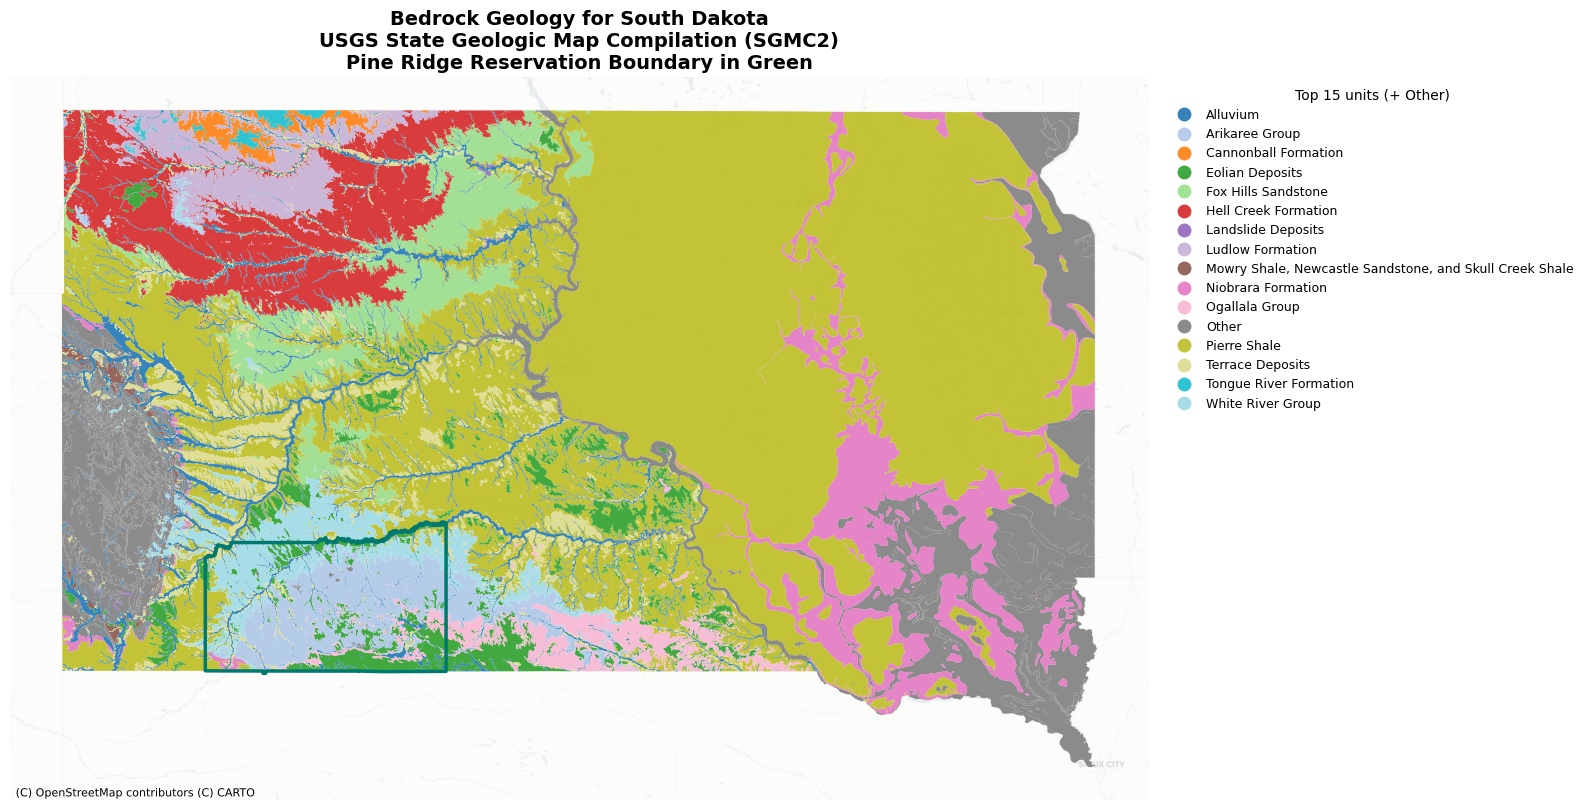

In [15]:
if not state_geo.empty:
    unit_col = "unit_name" if "unit_name" in state_geo.columns else "GENERALIZE"
    nb_gdf  = primary[primary["common_name"].str.contains("Oglala")]

    # Group all but the top N units into "Other" so the legend stays readable
    top_n = 15
    top_units = state_geo[unit_col].value_counts().head(top_n).index
    state_geo["_plot_unit"] = state_geo[unit_col].where(
        state_geo[unit_col].isin(top_units), "Other"
    )

    fig, ax = plt.subplots(1, 1, figsize=(16, 11))

    state_geo.to_crs(CRS_WEB).plot(
        ax=ax, column="_plot_unit", categorical=True,
        alpha=0.9, legend=True, cmap="tab20",
        legend_kwds={
            "fontsize": 9,
            "loc": "upper left",
            "bbox_to_anchor": (1.01, 1.0),
            "title": f"Top {top_n} units (+ Other)",
            "title_fontsize": 10,
            "frameon": False,
        }
    )

    if not nb_gdf.empty:
        nb_gdf.to_crs(CRS_WEB).plot(
            ax=ax, facecolor="none", edgecolor=TEAL,
            linewidth=2.5, zorder=5
        )

    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                        alpha=0.5, zoom=8)
    except Exception:
        pass

    ax.set_axis_off()
    ax.set_title(
        "Bedrock Geology for South Dakota\n"
        "USGS State Geologic Map Compilation (SGMC2)\n"
        "Pine Ridge Reservation Boundary in Green",
        fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    fig.savefig(FIGURES_DIR/"03_bedrock_geology.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Download state geology data and re-run. See cell 1 for instructions.")

## The Pierre Shale as a Dominant Bedrock Unit

The Pierre Shale deserves special attention because it controls more surface
processes on Pine Ridge and Rosebud than any other unit:

**Engineering properties:** The Pierre Shale contains abundant sodium
montmorillonite (smectite), an expansive clay mineral that swells
dramatically when wetted and shrinks on drying. This creates the
characteristic "popcorn" soil surface texture visible across the
reservations. Volume changes on the order of 30–40% are documented.
Roads, foundations, and pipelines built directly on Pierre Shale without
engineering mitigation fail predictably.

**Slope stability:** The Pierre Shale is the source of the widespread
landslides and slumps visible across valley walls throughout the study
area. When wetted, the smectite-rich layers become highly plastic and
will flow on slopes as gentle as 3–5 degrees.

**Drainage:** The Pierre Shale has very low permeability. It effectively
acts as a confining layer over deeper aquifers and generates high runoff
ratios during precipitation events contributing to flash flooding in
the White River system.

**Soils:** The dark, smectite-rich Vertisol soils (Houdek, Lakoma, and
related series) that cover much of both reservations are direct expressions
of the Pierre Shale parent material.

In [6]:
if not state_geo.empty and unit_col:
    geo_proj = state_geo.to_crs(CRS_PROJECTED)
    state_geo["area_km2"] = geo_proj.geometry.area / 1e6

    unit_areas = state_geo.groupby(unit_col)["area_km2"].sum().sort_values(ascending=False)
    total = unit_areas.sum()
    print("Bedrock unit areas (full dataset extent):")
    for u, a in unit_areas.head(15).items():
        print(f"  {str(u)[:40]:<40}: {a:>8.1f} km² ({a/total*100:>5.1f}%)")
else:
    print("Load state geology data to compute unit areas.")

Bedrock unit areas (full dataset extent):
  Pierre Shale                            :  96338.8 km² ( 49.0%)
  Niobrara Formation                      :  12629.7 km² (  6.4%)
  Hell Creek Formation                    :  12592.3 km² (  6.4%)
  Fox Hills Sandstone                     :   9093.7 km² (  4.6%)
  Carlile Shale                           :   8709.2 km² (  4.4%)
  Alluvium                                :   8124.8 km² (  4.1%)
  Eolian Deposits                         :   7095.3 km² (  3.6%)
  Terrace Deposits                        :   6329.0 km² (  3.2%)
  Arikaree Group                          :   6124.3 km² (  3.1%)
  White River Group                       :   5320.3 km² (  2.7%)
  Ludlow Formation                        :   4513.8 km² (  2.3%)
  Sioux Quartzite                         :   3799.2 km² (  1.9%)
  Ogallala Group                          :   3516.0 km² (  1.8%)
  water                                   :   1692.0 km² (  0.9%)
  Minnelusa Formation             

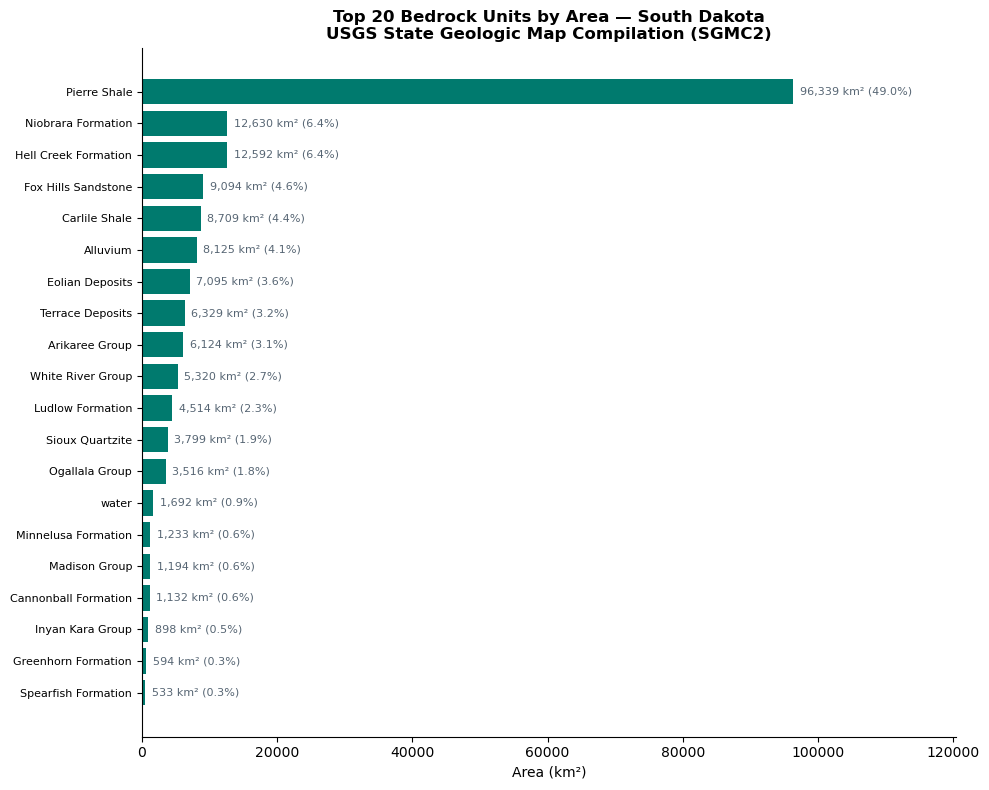

In [10]:
if not state_geo.empty and unit_col:
    top_n = 20
    plot_data = unit_areas.head(top_n).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(plot_data.index.astype(str), plot_data.values, color=TEAL)

    for bar, val in zip(bars, plot_data.values):
        pct = val / total * 100
        ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:,.0f} km² ({pct:.1f}%)", va="center", fontsize=8, color=GRAY)

    despine(ax)
    ax.set_xlabel("Area (km²)", fontsize=10)
    ax.set_title(f"Top {top_n} Bedrock Units by Area — South Dakota\n"
                 "USGS State Geologic Map Compilation (SGMC2)",
                 fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(0, plot_data.max() * 1.25)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR/"03_bedrock_unit_areas.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Load state geology data to compute unit areas.")

In [7]:
print(generate_citations(["usgs_state_geology","census_aiannh"]))

DATA CITATIONS

USGS Mineral Resources South Dakota State Geologic Map
  US Geological Survey, Mineral Resources Online Spatial Data. State Geologic Map Compilation. https://mrdata.usgs.gov/geology/state/
  https://mrdata.usgs.gov/geology/state/
  Steward: US Geological Survey | License: Public domain

US Census Bureau TIGER/Line AIANNH Boundaries
  US Census Bureau. TIGER/Line Shapefiles: American Indian / Alaska Native / Native Hawaiian Areas (AIANNH). https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
  https://www.census.gov/geographies/mapping-files/
  Steward: US Census Bureau | License: Public domain

TERRITORIAL PROVENANCE
  1868 Fort Laramie Treaty Oceti Sakowin territory, including the Great Sioux Reservation
  The lands of Pine Ridge and Rosebud Reservations are the sovereign territory of the Oglala Lakota and Sicangu Lakota peoples respectively. Federal and state geological surveys conducted on these lands do not transfer authority over su